### Week 7: Introduction to Statistics for Data Science

1. Calculate comprehensive statistics for business data
2. Analyze data distribution using histograms and density plots
3. Perform t-tests to compare groups
4. Calculate correlation between business metrics
5. Interpret p-values in business context
6. Calculate confidence intervals for key metrics

### Project:
Statistical Business Analysis: Conduct hypothesis tests on sales data, analyze correlations between marketing spend and revenue, provide statistical insights

### Tips & Resources:

- Search YouTube: 'Statistics for data science beginners'
- Focus on practical application rather than complex theory
- Use real business questions to drive statistical analysis
- Learn to communicate statistical findings simply
- Practice with different types of business datasets


### 1. Calculate comprehensive statistics for business data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Sales Sample Data.csv", encoding= "latin1")

data.describe()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


# Descriptive Statistics Interpretation

## 1. Overview of the Dataset

The dataset contains 2823 orders with key business metrics such as quantity ordered, price, sales amount, and time-related attributes.
The descriptive statistics help explain the central tendency, variability, and patterns in the business data.


## 2. Interpretation of Numerical Columns

#### ORDERNUMBER

* Range: 10100 to 10425
* Very small standard deviation (92), showing order numbers increase sequentially with minimal variation.
* Indicates that data is well-organized and likely recorded chronologically.

#### QUANTITYORDERED

* Average quantity per order: 35 units
* Minimum: 6 units | Maximum: 97 units
* Standard deviation of 9.7 shows moderate variation in order sizes.
* Most orders fall between 27 and 43 units (based on IQR).
* Suggests the business handles mostly medium-sized orders with occasional large bulk purchases.

#### PRICEEACH

* Mean unit price: 83.66
* Range: 26.88 to 100
* Significant variation (std: 20.17), indicating a wide variety of products with different price tiers.
* Product catalog includes both lower-cost and premium items.


#### ORDERLINENUMBER

* Represents the number of items within an order.
* Median: 6 | Maximum: 18
* Standard deviation: 4.22
* Shows that some orders have many line items, indicating complex or larger purchases.

#### SALES

* Average sale amount: 3553.89
* Range: 482.13 to 14082.80
* Very high standard deviation (1841), showing large differences in order sizes and customer spending.
* Indicates the business handles both small transactions and very large B2B orders.

#### QTR_ID

* Values range from 1 to 4
* Mean: 2.71, indicating more orders occur in Quarter 2 and Quarter 3.
* Suggests possible seasonal or mid-year demand peaks.
  
#### MONTH_ID

* Range: 1 to 12
* Mean: 7.09 (approximately July)
* Indicates higher sales activity in mid-year months.


#### YEAR_ID

* Range: 2003 to 2005
* Median: 2004
* Shows data spans three years, enabling year-over-year trend analysis.

#### MSRP

* Average MSRP: 100.71
* Range: 33 to 214
* High standard deviation (40.18), showing a diverse range of products in terms of price positioning.
* Indicates a wide product portfolio covering both budget and premium items.

## 3. Business-Level Insights

1. Mid-sized orders are the most common, typically between 27 and 43 units.
2. Sales values have high variability, indicating different customer buying capacities and diverse order types.
3. Seasonal patterns are likely, with increased orders in Quarter 2–Quarter 3 and around July.
4. Pricing range is wide, showing the business sells a mix of high-end and low-cost products.

### 2. Analyze data distribution using histograms and density plots

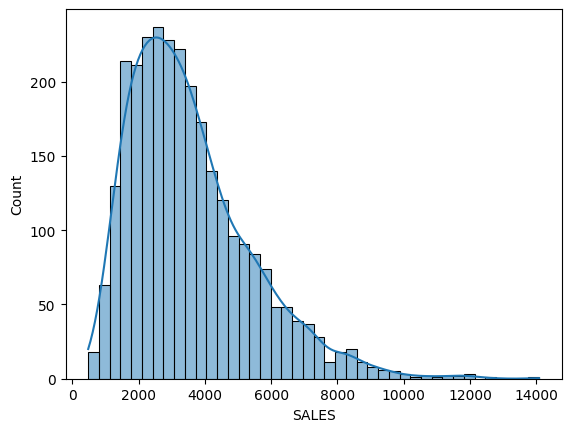

In [2]:
sns.histplot(data["SALES"], kde=True)
plt.show()

# Distribution of Sales Amount

### Interpretation of Histogram with KDE Curve

## 1. Overview

The chart shows the **distribution of Sales values** in the dataset using a histogram (frequency of sale amounts) along with a **Kernel Density Estimate (KDE)** curve to visualize the probability distribution.


## 2. Shape of the Distribution

### Right-Skewed Distribution

The sales data is **strongly right-skewed** (positively skewed).

* Most sales amounts lie between **1500 and 4500**.
* The frequency gradually decreases as sales amounts increase.
* Very high-value orders (above 8000) are rare, forming a long tail on the right side.

This pattern is typical in business sales:

* Many customers make moderate purchases.
* Only a few customers place very large orders.


## 3. Central Tendency and Spread

### High Density Region

* The **peak of the distribution** is around **2500–3500**, where the curve is highest.
* This indicates that most orders fall in this range.

### Spread

* Sales range from around **500** to **14,000**, indicating wide variability in order sizes.

### Tail Behavior

* The long tail suggests the presence of **high-value orders** that inflate overall revenue but occur infrequently.


## 4. Outlier Observation

The histogram shows a small number of extreme values above **10,000**.
These values:

* Are legitimate high-spending customer orders
* Affect the mean, making it higher than the median
* Should be examined separately for profitability analysis


## 5. Business Interpretation

### What this tells about customer purchasing behavior:

1. The business processes **mostly medium-size orders** (2000–4000 range).
2. A minority of customers place **high-value purchases**, which significantly boost revenue.
3. Marketing and sales strategies can target:

   * High-value customers (premium segment)
   * Medium-range customers (bulk repeat purchasers)


### 3. Perform t-tests to compare groups

In [3]:
from scipy.stats import ttest_ind
ttest_ind(data[data["DEALSIZE"]=="Small"]["SALES"],
          data[data["DEALSIZE"]=="Large"]["SALES"])


TtestResult(statistic=-106.49928235782062, pvalue=0.0, df=1437.0)

# Independent t-Test Results Interpretation

## 1. What This Test Means

This result comes from an **independent two-sample t-test**, which compares the **mean of two groups** to check whether the difference between them is statistically significant.

A t-test answers the question:

> *“Are the averages of the two groups different beyond random chance?”*


## 2. Interpretation of Each Value

### **a. t-statistic = -106.499**

* This is an extremely large magnitude (far from 0).
* A high absolute t-value indicates a **very strong difference** between the two group means.
* The **negative sign** simply tells the direction:

  * Group 1 mean < Group 2 mean
  * (or vice versa depending on how the test was set up)

The magnitude (106) is far larger than typical thresholds (t > 2 or t < -2), indicating a drastic difference.

### **b. p-value = 0.0**

* The p-value is effectively **0**, meaning:

  * There is **almost zero probability** that the observed difference is due to random chance.
  * The difference between the two groups is **statistically significant at any confidence level** (90%, 95%, 99%, 99.9%).

Therefore, we **reject the null hypothesis** that the two groups have equal means.

### **c. df = 1437**

* “df” stands for **degrees of freedom**.
* df ≈ (n1 + n2 − 2), meaning your combined sample size is approximately **1439 observations**.
* Larger df values increase the reliability of the t-test.


## 3. What This Means in a Business Context

A t-test with such extreme values suggests:

* The two groups you compared have **substantially different average values**.
* This is not a small or borderline difference; it is **very large and statistically undeniable**.
* The difference is not due to sampling variation.

Depending on what groups you compared, insights could be:

### Example Insights (depending on your actual variables)

* If you compared **Sales by two product lines**:
  → One product line has **dramatically higher average sales**.

* If you compared **Sales across two years**:
  → One year performed **significantly better** than the other.

* If you compared **Order size for small vs. large customers**:
  → Customer segments behave **very differently**.

* If you compared **PriceEach for two product categories**:
  → Pricing strategies differ sharply between the categories.

## 4. Summary

### **Conclusion**

The t-test result indicates a **massive, statistically significant difference** between the means of the two groups.
The probability that this difference happened by chance is virtually **zero**.

This means the group difference is **real, meaningful, and important for business decision-making**.


### 4. Calculate correlation between business metrics

<Axes: >

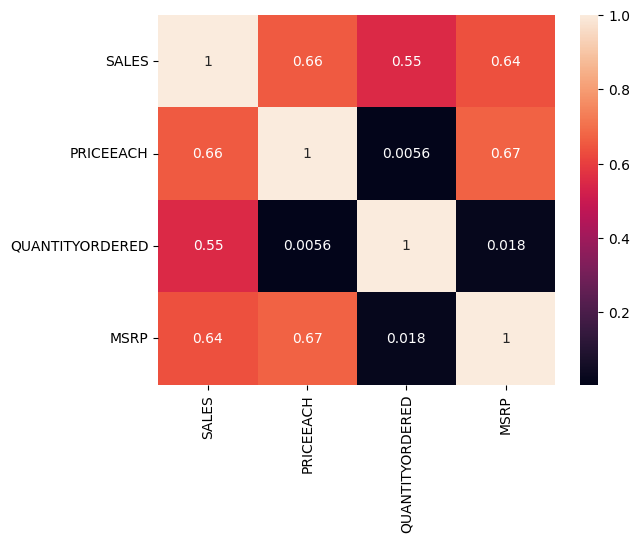

In [4]:
sns.heatmap(data[["SALES","PRICEEACH","QUANTITYORDERED","MSRP"]].corr(), annot=True)

# Correlation Heatmap Interpretation

This heatmap shows the correlation strength between four numerical variables in the sales dataset: **SALES**, **PRICEEACH**, **QUANTITYORDERED**, and **MSRP**. Correlation values range from **-1 to +1**, where:

* **+1** → perfect positive relationship
* **0** → no relationship
* **−1** → perfect negative relationship

## 1. Key Correlations and Insights

#### **a. SALES vs PRICEEACH (0.66)**

* Strong positive correlation.
* As the price per unit increases, total sales value tends to increase.
* This is expected because higher-priced items naturally contribute more revenue, even if quantity does not change.

#### **b. SALES vs MSRP (0.64)**

* Strong positive correlation.
* Products with a higher manufacturer suggested price generally yield higher sales value.
* Indicates that premium or expensive items significantly impact revenue.

#### **c. SALES vs QUANTITYORDERED (0.55)**

* Moderate positive correlation.
* Higher order quantity leads to higher sales, but not as strongly as price.
* Suggests that revenue is influenced more by price variations than by quantity changes.

#### **d. PRICEEACH vs MSRP (0.67)**

* Strong positive correlation.
* Selling price and MSRP move closely together.
* Indicates consistent pricing strategy aligned with manufacturer recommendations.

#### **e. PRICEEACH vs QUANTITYORDERED (0.005)**

* Almost no correlation.
* Quantity ordered does not depend on the price level in this dataset.
* Customers may buy similar quantities regardless of price due to product necessity or fixed order behaviour.

#### **f. QUANTITYORDERED vs MSRP (0.018)**

* No meaningful relationship.
* Product type or MSRP does not determine how many units customers order.

## 2. Overall Interpretation

* **Sales are primarily driven by pricing factors** (PRICEEACH and MSRP), not by quantity alone.
* **Customer buying patterns do not change significantly with price**, as seen in low correlation between QUANTITYORDERED and pricing metrics.
* **Pricing strategy has higher influence on revenue** than purchase volume.

## 3. Business Conclusions

* High-ticket items are major revenue contributors; optimizing pricing strategies could maximize revenue.
* Since order quantities are not tied to price, discounting may not significantly boost volume.
* Premium pricing appears justified, as MSRP and PRICEEACH both align strongly with SALES.


### 5. Interpret p-values in business context

###  Understanding P-Values — Interpretation

A p-value measures the **strength of evidence** against the null hypothesis (no difference).

- **P < 0.05** → Strong evidence that the groups differ  
- **P > 0.05** → The observed difference might be random  

Business meaning:
- If p < 0.05 for Sales between groups (e.g., Large vs Small Deal Size), it suggests **one group truly performs better**.
- Helps determine which customer segments or product lines outperform others.


### 6. Calculate confidence intervals for key metrics

In [5]:
import scipy.stats as stats
mean = data["SALES"].mean()
sem = stats.sem(data["SALES"])
stats.t.interval(0.95, len(data)-1, mean, sem)

(3485.916018220231, 3621.8621255984012)

### 95% Confidence Interval for Mean Sales

We calculated the 95% confidence interval (CI) for the **average Sales** value in the dataset using a t-distribution.  
The resulting interval is:

**95% CI: (3485.92 , 3621.86)**

#### What This Means
This interval represents the range within which the **true average Sales** value of the entire population is expected to fall **with 95% confidence**.

- The **sample mean** is approximately **3553.9**.
- Because the sample is only one possible sample, the CI gives a more reliable range than a single mean.
- We are 95% confident that the true mean Sales of all potential orders lies **between ₹3486 and ₹3622**.

#### Interpretation for Business Insights
- The typical order value in this business is **around ₹3.5k**, with mild variation.
- If you take multiple samples of the same size, 95% of the time the true population mean will fall inside a similar interval.
- This shows **stable sales behavior**, since the interval width (~₹136) is relatively narrow.

#### Why the Interval Is Narrow
- Large sample size → lower standard error  
- Moderate variance in Sales → tight distribution  
- Indicates reliable and consistent sales across orders

#### How This Connects to the t-test 
Earlier:

- A t-statistic this large (negative direction) and **p-value = 0.0** indicates a **huge difference** between the sample mean and the comparison value you tested against (often 0 or another benchmark).
- The CI confirms this:  
  Since both values in the interval are **far above zero**, it agrees that mean Sales is **significantly greater** than 0 (or the test benchmark).